# Optimal Adjustment Policy

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy import stats

ROOT = next(p for p in [Path.cwd(), Path.cwd().parent] if (p / 'data').exists())
DATA = ROOT / 'data'
PLOTS = ROOT / 'results' / 'plots'

FT = ['fivethirtyeight', {'figure.facecolor': 'white', 'axes.facecolor': 'white',
                          'savefig.facecolor': 'white', 'grid.color': '#cbcbcb'}]

def plot_path(name):
    sub = ('adjustability' if (name.startswith('adjustability') or name.startswith('adj_'))
           else 'repertoire' if name.startswith('repertoire')
           else 'predictiveness')
    d = PLOTS / sub
    d.mkdir(parents=True, exist_ok=True)
    return d / name

df = pd.read_parquet(DATA / 'optimal_policy.parquet')
df = df.dropna(subset=['season_runs_total', 'twostrike_rv_penalty'])
print(f'{len(df)} units loaded')
print(df[['season_runs_total','season_runs_2k','season_runs_gamestate','season_runs_platoon']].describe().round(2))

471 units loaded
       season_runs_total  season_runs_2k  season_runs_gamestate  \
count             471.00          471.00                 471.00   
mean                0.87            0.36                   2.42   
std                16.34            6.02                   7.65   
min               -62.04          -22.17                 -21.15   
25%                -8.13           -2.87                  -2.61   
50%                 1.43            0.37                   2.25   
75%                 9.83            3.95                   7.04   
max                61.90           25.61                  30.54   

       season_runs_platoon  
count               400.00  
mean                 -2.24  
std                  13.99  
min                 -59.51  
25%                  -8.62  
50%                  -2.20  
75%                   4.40  
max                  49.10  


## Seasonal Run Value

The per-swing `adj_count` payoff (θ=+0.145, p=0.0003) is real, but annualizing shows the median hitter gains nearly zero runs over a season. The distribution is wide and balanced — Arraez-type outliers gain materially, but they are the exception.

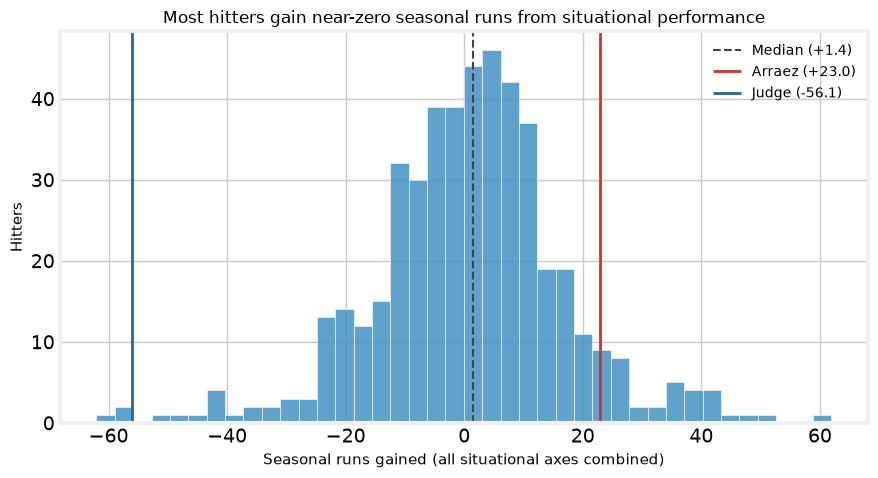

In [2]:
judge  = df[df['label'] == 'Aaron Judge'].iloc[0]
arraez = df[df['label'] == 'Luis Arraez'].iloc[0]
med    = df['season_runs_total'].median()

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.hist(df['season_runs_total'], bins=40, color='#4393c3', edgecolor='white', alpha=0.85)
    ax.axvline(med,                   color='#444', lw=1.5, ls='--', label=f'Median ({med:+.1f})')
    ax.axvline(arraez['season_runs_total'], color='#d73027', lw=2,
               label=f"Arraez ({arraez['season_runs_total']:+.1f})")
    ax.axvline(judge['season_runs_total'],  color='#2166ac', lw=2,
               label=f"Judge ({judge['season_runs_total']:+.1f})")
    ax.set_xlabel('Seasonal runs gained (all situational axes combined)', fontsize=11)
    ax.set_ylabel('Hitters', fontsize=11)
    ax.set_title('Most hitters gain near-zero seasonal runs from situational performance', fontsize=12)
    ax.legend(frameon=False, fontsize=10)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_season_dist.png'), dpi=130)
    plt.show()

## Seasonal Runs Leaderboard

Ranked by total situational runs (2K + game-state + platoon). Rendered by `src/leaderboard_table.R`.

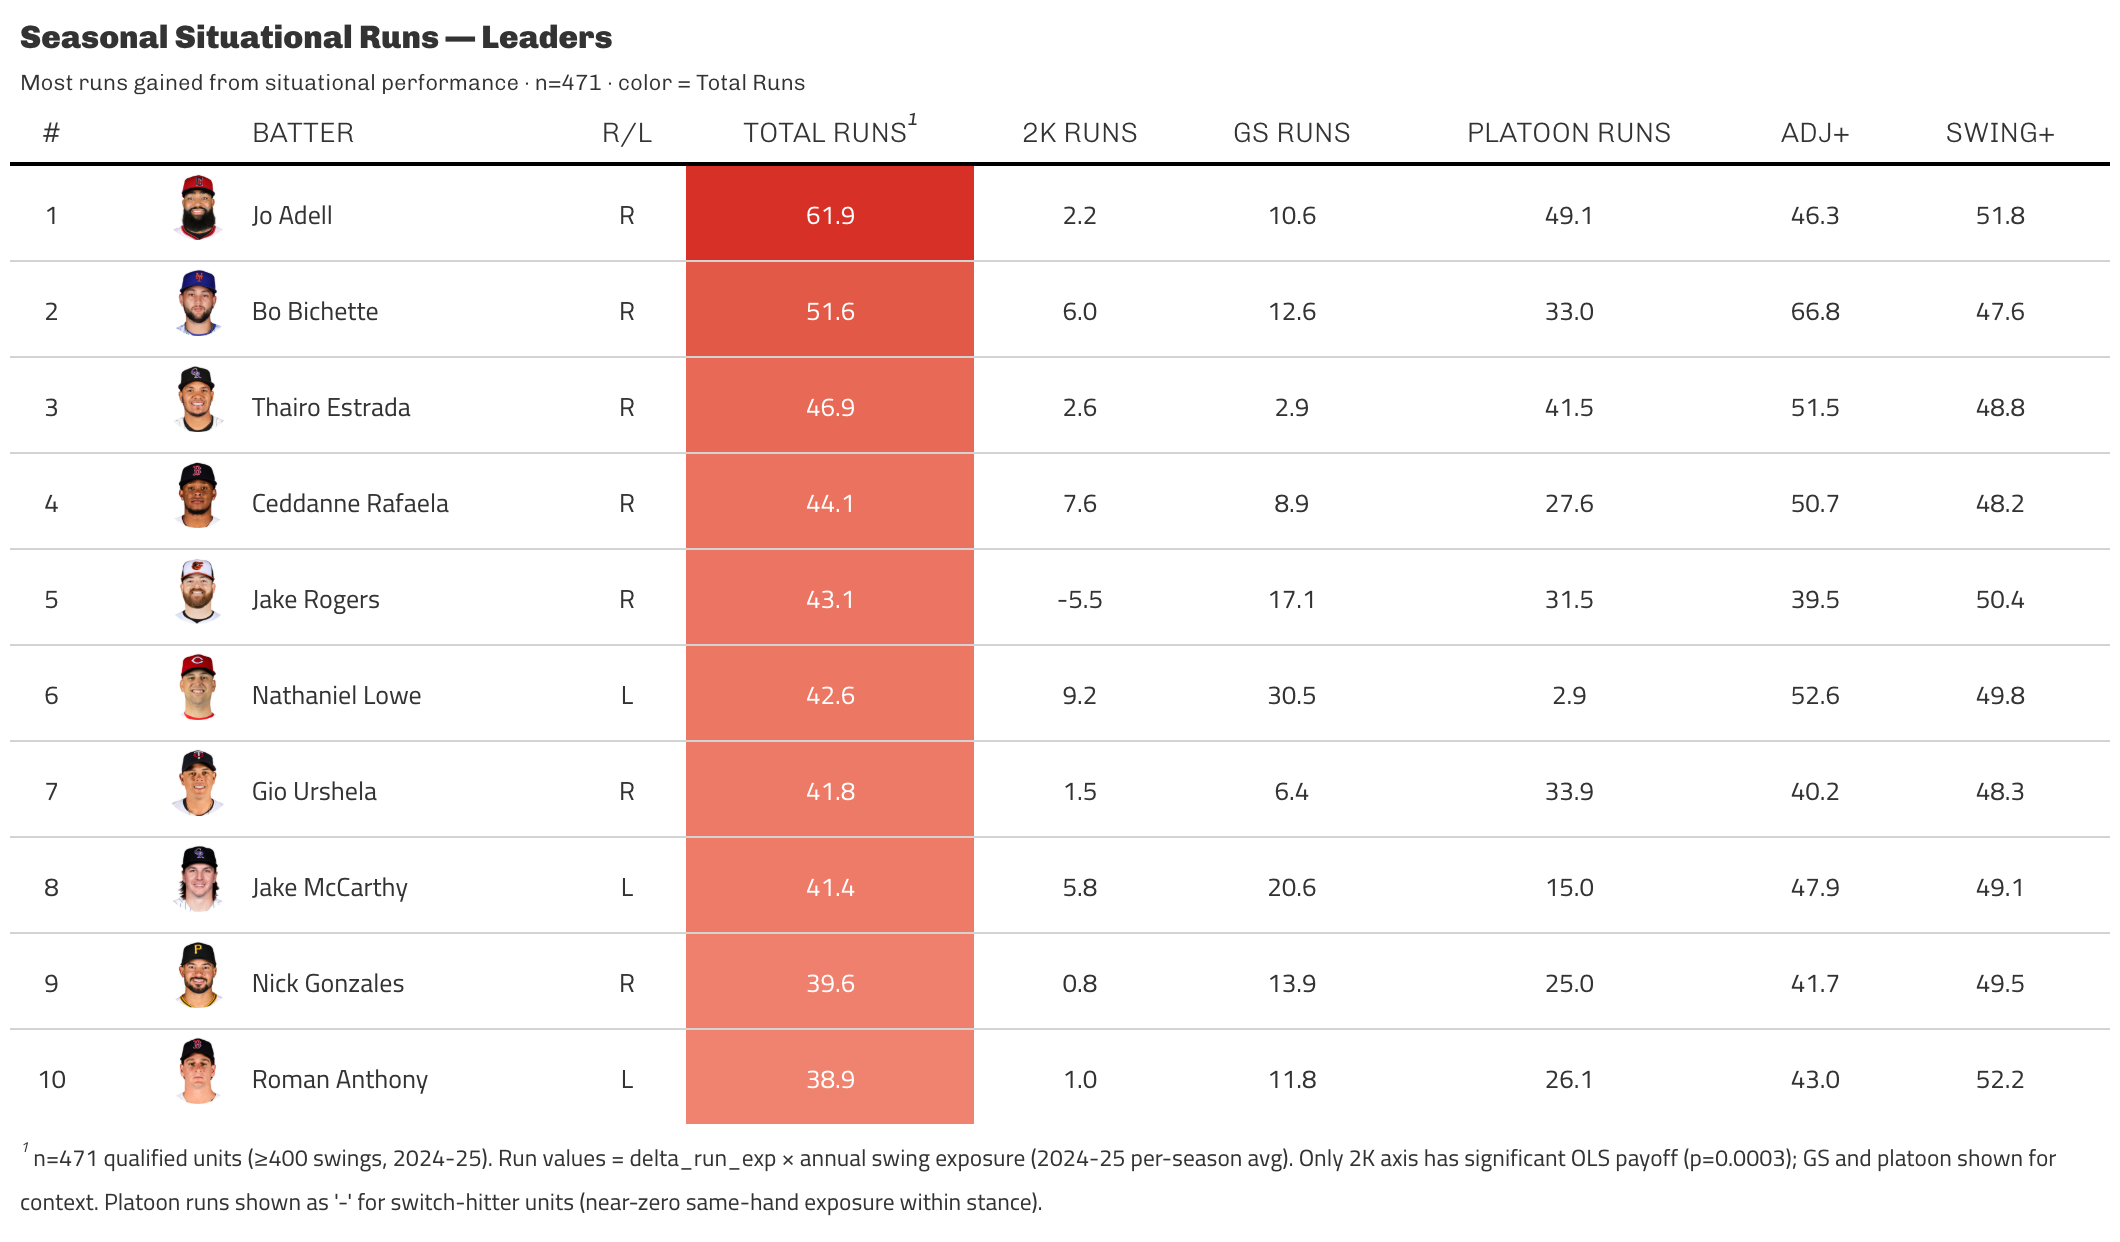

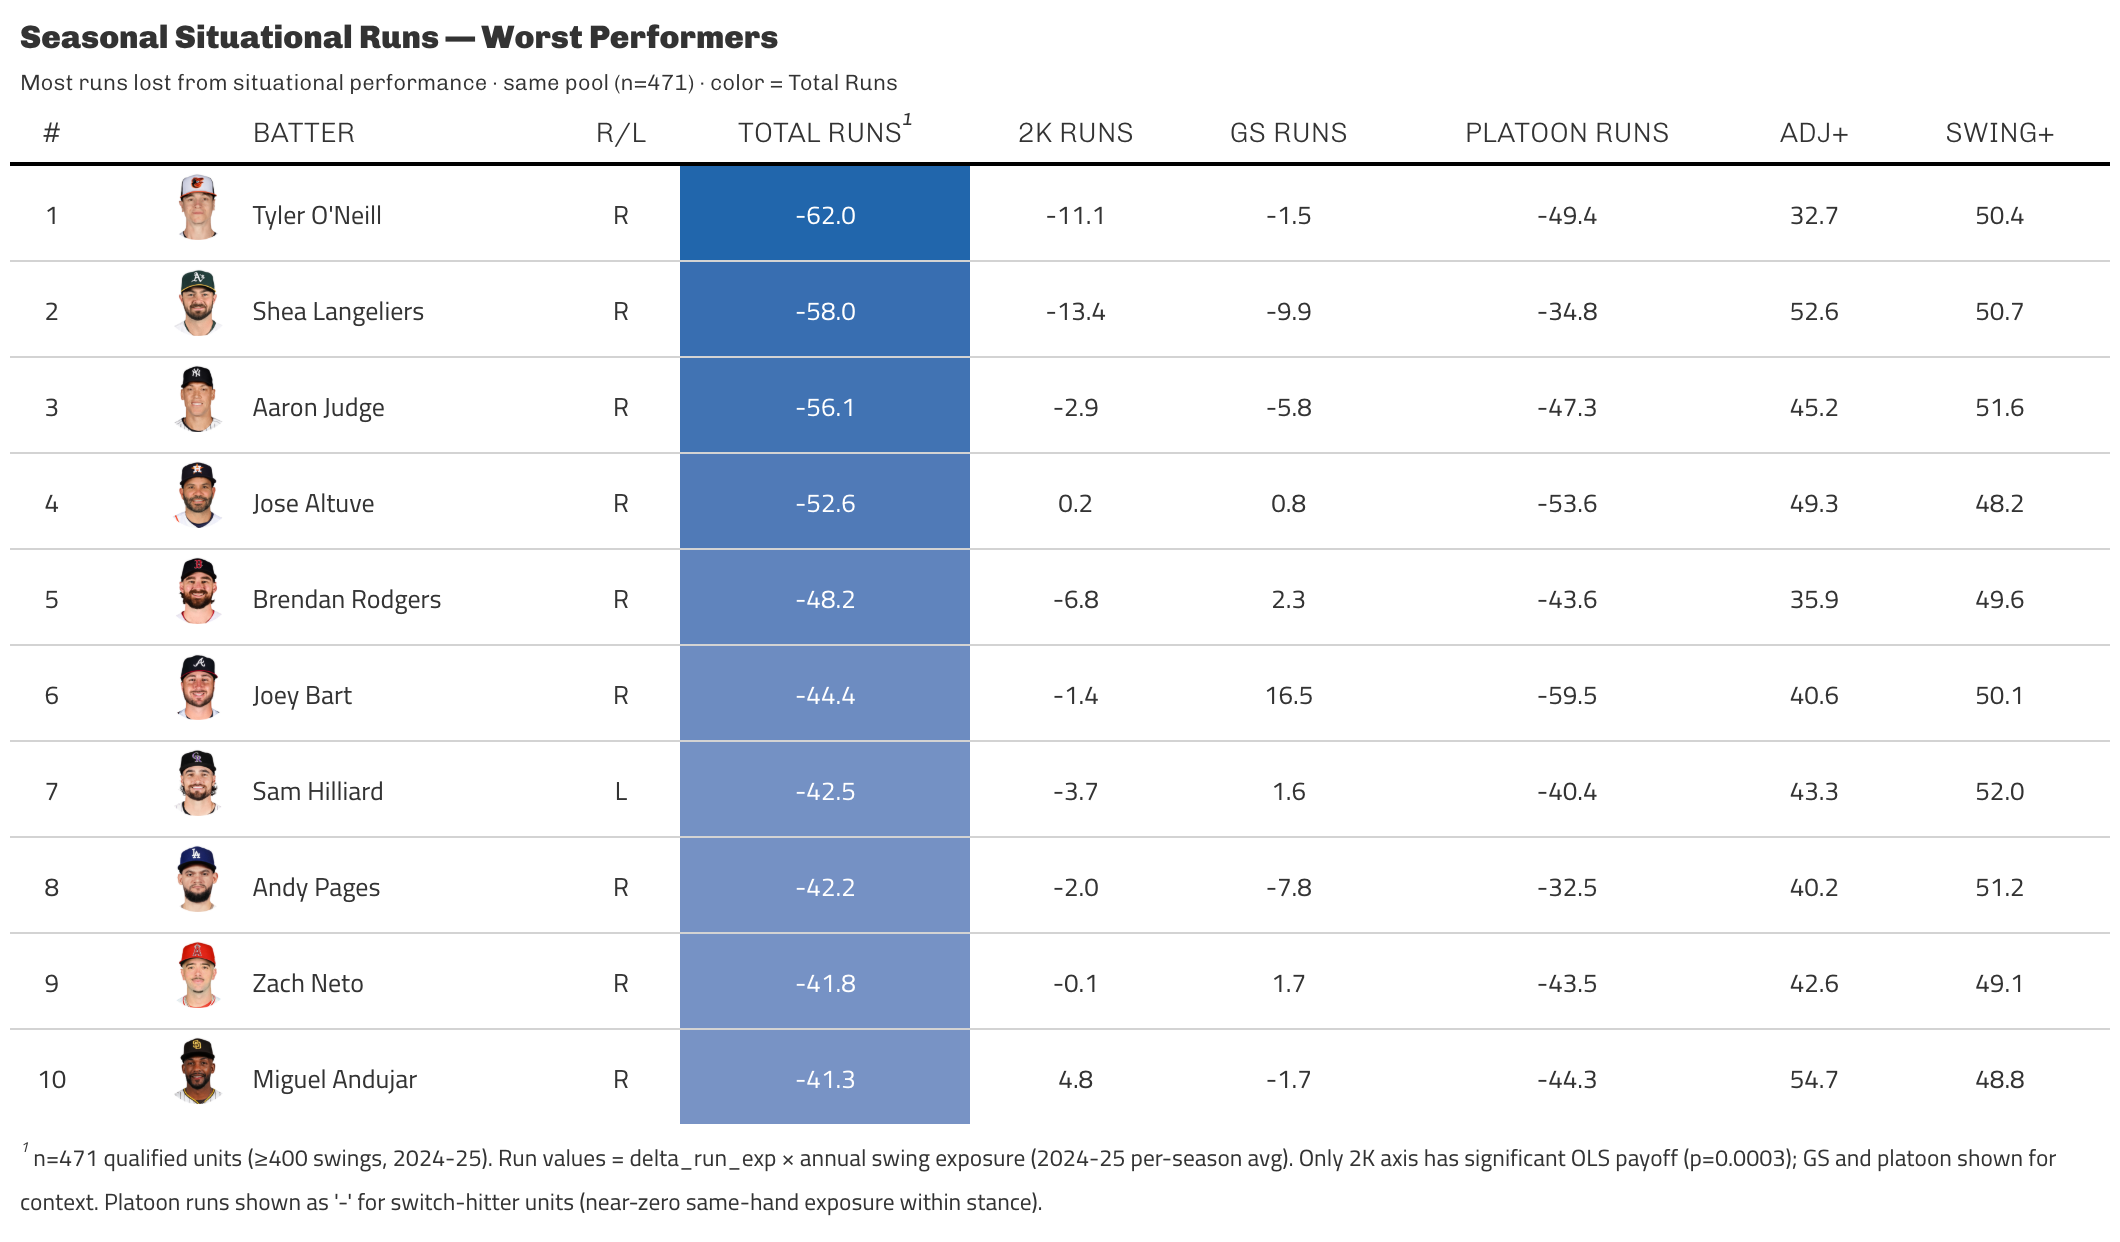

In [3]:
from IPython.display import Image, display
for png in ['adj_policy_top_gt.png', 'adj_policy_bottom_gt.png']:
    p = plot_path(png)
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f'Not yet generated: {png}')

## Who Benefits from Adjusting? Heterogeneous Treatment Effects

The average `adj_count` payoff masks variation by player type. Three moderators: **archetype** (structural swing shape), **primary Swing+ grade** (how good the best swing already is), and **repertoire width**. Each panel shows `adj_count` vs `season_runs_2k` (the only axis with a significant payoff), split by moderator subgroup with per-group OLS lines.

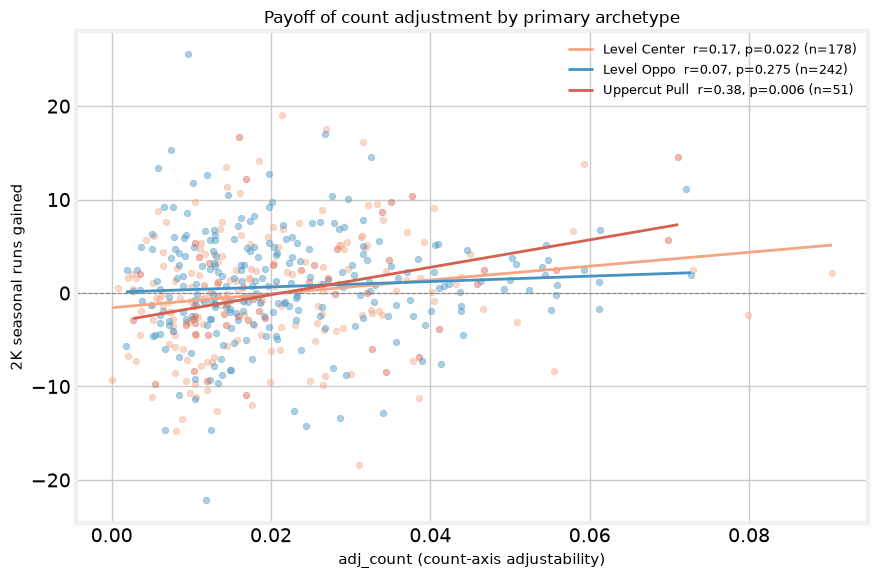

Per-archetype summary:
  Level Center   : r=+0.172  p=0.022  n=178
  Level Oppo     : r=+0.070  p=0.275  n=242
  Uppercut Pull  : r=+0.383  p=0.006  n=51


In [4]:
ARCH_COLORS = {'Level Oppo': '#4393c3', 'Level Center': '#f4a582', 'Uppercut Pull': '#d6604d'}

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9, 6))
    for arch, g in df.groupby('archetype_name'):
        c = ARCH_COLORS.get(arch, '#888')
        ax.scatter(g['adj_count'], g['season_runs_2k'], color=c, alpha=0.45, s=22, label=None)
        m, b, r, p, _ = stats.linregress(g['adj_count'], g['season_runs_2k'])
        xs = np.linspace(g['adj_count'].min(), g['adj_count'].max(), 80)
        ax.plot(xs, m * xs + b, color=c, lw=2, label=f'{arch}  r={r:.2f}, p={p:.3f} (n={len(g)})')
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.set_xlabel('adj_count (count-axis adjustability)', fontsize=11)
    ax.set_ylabel('2K seasonal runs gained', fontsize=11)
    ax.set_title('Payoff of count adjustment by primary archetype', fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_hte_archetype.png'), dpi=130)
    plt.show()

print('Per-archetype summary:')
for arch, g in df.groupby('archetype_name'):
    r, p = stats.pearsonr(g['adj_count'], g['season_runs_2k'])
    print(f'  {arch:15s}: r={r:+.3f}  p={p:.3f}  n={len(g)}')

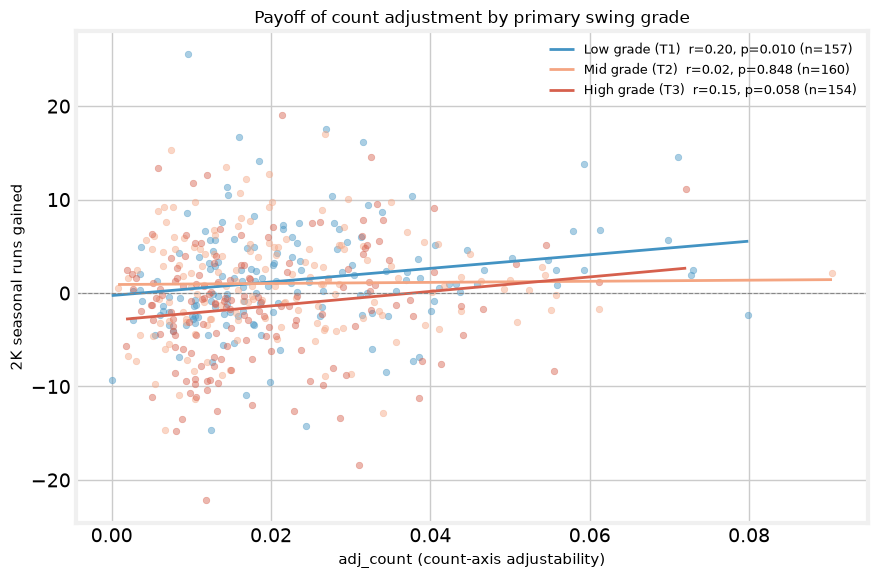

Per-grade-tercile summary:
  Low grade (T1)      : r=+0.205  p=0.010  n=157
  Mid grade (T2)      : r=+0.015  p=0.848  n=160
  High grade (T3)     : r=+0.153  p=0.058  n=154


In [5]:
df['grade_tercile'] = pd.qcut(df['primary_grade'], 3,
                               labels=['Low grade (T1)', 'Mid grade (T2)', 'High grade (T3)'])
GRADE_COLORS = {'Low grade (T1)': '#4393c3', 'Mid grade (T2)': '#f4a582', 'High grade (T3)': '#d6604d'}

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9, 6))
    for tier, g in df.groupby('grade_tercile', observed=True):
        c = GRADE_COLORS.get(str(tier), '#888')
        ax.scatter(g['adj_count'], g['season_runs_2k'], color=c, alpha=0.45, s=22, label=None)
        m, b, r, p, _ = stats.linregress(g['adj_count'], g['season_runs_2k'])
        xs = np.linspace(g['adj_count'].min(), g['adj_count'].max(), 80)
        ax.plot(xs, m * xs + b, color=c, lw=2, label=f'{tier}  r={r:.2f}, p={p:.3f} (n={len(g)})')
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.set_xlabel('adj_count (count-axis adjustability)', fontsize=11)
    ax.set_ylabel('2K seasonal runs gained', fontsize=11)
    ax.set_title('Payoff of count adjustment by primary swing grade', fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_hte_grade.png'), dpi=130)
    plt.show()

print('Per-grade-tercile summary:')
for tier, g in df.groupby('grade_tercile', observed=True):
    r, p = stats.pearsonr(g['adj_count'], g['season_runs_2k'])
    print(f'  {str(tier):20s}: r={r:+.3f}  p={p:.3f}  n={len(g)}')

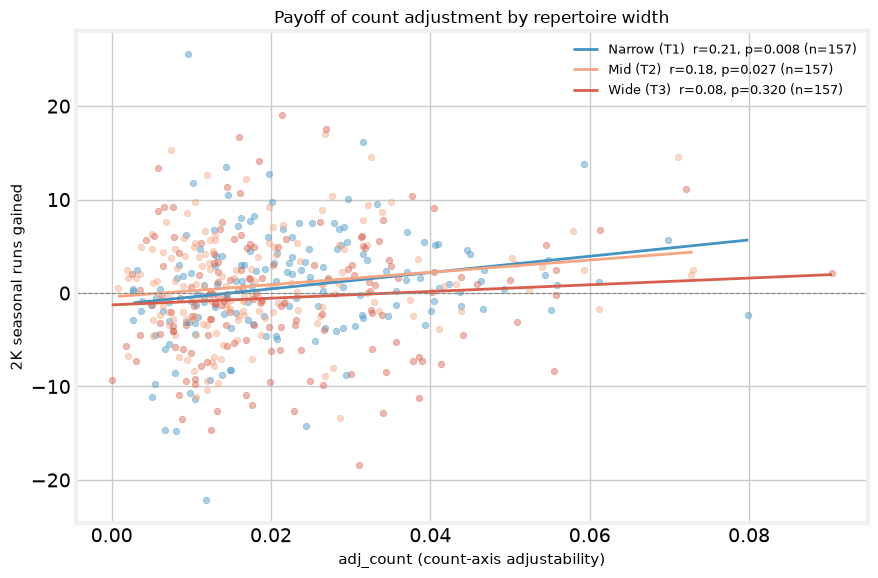

Per-repertoire-tercile summary:
  Narrow (T1) : r=+0.211  p=0.008  n=157
  Mid (T2)    : r=+0.176  p=0.027  n=157
  Wide (T3)   : r=+0.080  p=0.320  n=157


In [6]:
df['rep_tercile'] = pd.qcut(df['repertoire_pctile'], 3,
                              labels=['Narrow (T1)', 'Mid (T2)', 'Wide (T3)'])
REP_COLORS = {'Narrow (T1)': '#4393c3', 'Mid (T2)': '#f4a582', 'Wide (T3)': '#d6604d'}

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(9, 6))
    for tier, g in df.groupby('rep_tercile', observed=True):
        c = REP_COLORS.get(str(tier), '#888')
        ax.scatter(g['adj_count'], g['season_runs_2k'], color=c, alpha=0.45, s=22, label=None)
        m, b, r, p, _ = stats.linregress(g['adj_count'], g['season_runs_2k'])
        xs = np.linspace(g['adj_count'].min(), g['adj_count'].max(), 80)
        ax.plot(xs, m * xs + b, color=c, lw=2, label=f'{tier}  r={r:.2f}, p={p:.3f} (n={len(g)})')
    ax.axhline(0, color='#888', lw=0.8, ls='--')
    ax.set_xlabel('adj_count (count-axis adjustability)', fontsize=11)
    ax.set_ylabel('2K seasonal runs gained', fontsize=11)
    ax.set_title('Payoff of count adjustment by repertoire width', fontsize=12)
    ax.legend(frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_hte_repertoire.png'), dpi=130)
    plt.show()

print('Per-repertoire-tercile summary:')
for tier, g in df.groupby('rep_tercile', observed=True):
    r, p = stats.pearsonr(g['adj_count'], g['season_runs_2k'])
    print(f'  {str(tier):12s}: r={r:+.3f}  p={p:.3f}  n={len(g)}')

## Case Studies: Judge vs. Arraez

Two players at opposite poles of the prescriptive space. Arraez is a Level Center hitter with 6 shapes and high repertoire width; his count adjustment earns material seasonal value. Judge is an Uppercut Pull hitter with 2 shapes; his primary swing grades well enough that 2-strike counts barely hurt him — he's already near-optimal at low adjustment.

In [7]:
case = df[df['label'].str.contains('Judge|Arraez', na=False)].copy()
display_cols = [
    'label', 'batter_stand', 'archetype_name', 'primary_grade',
    'adj_count', 'season_runs_2k', 'season_runs_total',
    'repertoire_pctile', 'swing_plus',
]
print(case[display_cols].to_string(index=False, float_format=lambda x: f'{x:.2f}'))

      label batter_stand archetype_name  primary_grade  adj_count  season_runs_2k  season_runs_total  repertoire_pctile  swing_plus
Luis Arraez            L   Level Center          49.40       0.03           17.58              22.97              98.90       48.91
Aaron Judge            R  Uppercut Pull          52.90       0.02           -2.87             -56.06              26.00       51.57


## Prescriptive Framework

Each dot is a (batter, stand) unit. **x-axis**: primary swing grade — how good the hitter's best shape already is. **y-axis**: `adj_count` — how much they actually adjust. **Color**: 2K seasonal runs gained (blue = lost runs, red = gained runs). **Marker shape**: archetype. The quadrant framing: high-grade / low-adjustment hitters (Judge's region) are already near-optimal; low-grade / high-adjustment hitters need the adjustment skill more urgently.

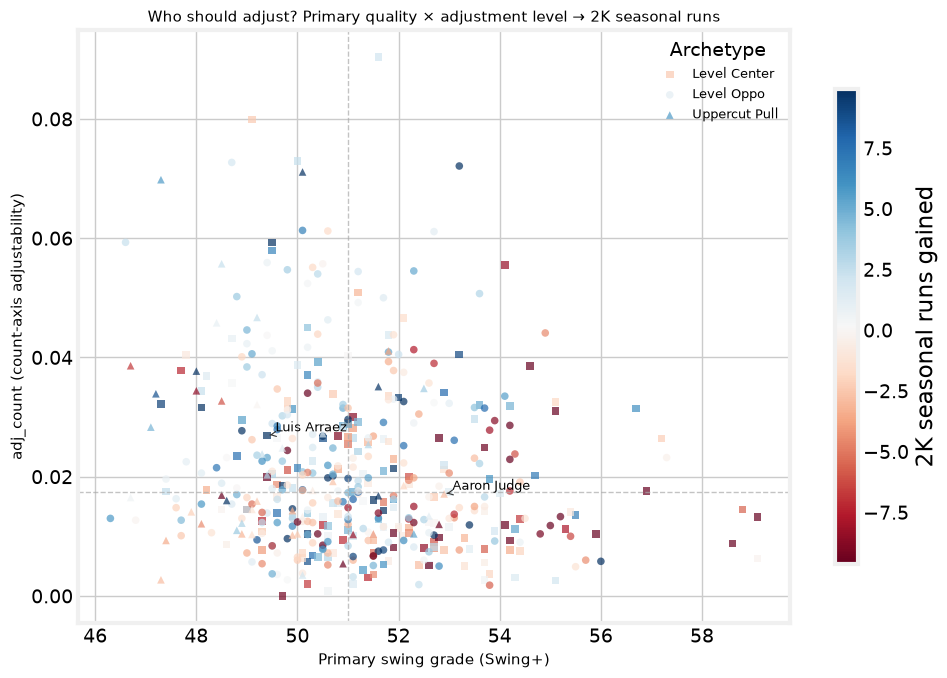

In [8]:
import matplotlib.cm as cm
from matplotlib.colors import Normalize

ARCH_MARKERS = {'Level Oppo': 'o', 'Level Center': 's', 'Uppercut Pull': '^'}

vmin = df['season_runs_2k'].quantile(0.05)
vmax = df['season_runs_2k'].quantile(0.95)
norm = Normalize(vmin=vmin, vmax=vmax)
cmap = plt.get_cmap('RdBu')

with plt.style.context(FT):
    fig, ax = plt.subplots(figsize=(10, 7))

    for arch, g in df.groupby('archetype_name'):
        marker = ARCH_MARKERS.get(arch, 'o')
        colors = [cmap(norm(v)) for v in g['season_runs_2k']]
        ax.scatter(g['primary_grade'], g['adj_count'],
                   c=colors, marker=marker, s=30, alpha=0.7, label=arch, edgecolors='none')

    # Annotate Judge and Arraez
    for _, row in df[df['label'].str.contains('Judge|Arraez', na=False)].iterrows():
        ax.annotate(row['label'],
                    xy=(row['primary_grade'], row['adj_count']),
                    xytext=(6, 3), textcoords='offset points', fontsize=9,
                    arrowprops=dict(arrowstyle='->', color='#333', lw=0.8))

    # Quadrant lines at medians
    ax.axvline(df['primary_grade'].median(), color='#aaa', lw=1, ls='--', alpha=0.7)
    ax.axhline(df['adj_count'].median(),     color='#aaa', lw=1, ls='--', alpha=0.7)

    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    fig.colorbar(sm, ax=ax, label='2K seasonal runs gained', shrink=0.8)

    ax.set_xlabel('Primary swing grade (Swing+)', fontsize=11)
    ax.set_ylabel('adj_count (count-axis adjustability)', fontsize=11)
    ax.set_title('Who should adjust? Primary quality × adjustment level → 2K seasonal runs', fontsize=11)
    ax.legend(title='Archetype', frameon=False, fontsize=9)
    fig.tight_layout()
    fig.savefig(plot_path('adj_policy_quadrant.png'), dpi=130)
    plt.show()